# Aerosol measurements at Mt. Kenya
Read an plot the prepared (level 2) aerosol measurements 

In [1]:
# import 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import itertools
import xarray as xr
import sys
from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt
from os import PathLike
from pathlib import Path
import zipfile
import matplotlib.dates as mdates
import matplotlib.lines as mlines

from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/
from utils import process_data
from input import read_aerosols

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

#save figures in...
dir_save = './output/aerosols/' #without_event/'
save_fig = True

### Read the data

In [2]:
# Read in aerosol data from aethalometer and nephelometer
aerosol_data_dir = "../data/level2/L2_AEROSOL_data_bachelorthesis Mike Baumann"
ds_ae, ds_neph = read_aerosols.aerosol_data_to_dataset(aerosol_data_dir)

# make a full dataset with wavelength dependence and calculated aerosol properties (SAE, SSA, AAE)
ds_aerosols = read_aerosols.aerosols_to_full_dataset(ds_ae, ds_neph)
ds_aerosols

/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:108: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_ae = pd.read_csv(
/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:117: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_neph = pd.read_csv(
/bigdat/leob/kadi_py311/lib64/python3.11/site-packages/xarray/core/computation.py:824: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/bigdat/leob/kadi_py311/lib64/python3.11/site-packages/xarray/core/computation.py:824: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/bigdat/leob/kadi_py311/lib64/python3.11/site-package

<xarray.Dataset> Size: 6MB
Dimensions:           (time: 27781, lambda_abs: 7, lambda_scat: 3)
Coordinates:
  * time              (time) datetime64[ns] 222kB 2019-03-25T12:00:00 ... 202...
  * lambda_abs        (lambda_abs) int64 56B 370 470 521 590 660 880 950
  * lambda_scat       (lambda_scat) int64 24B 450 525 635
Data variables:
    abs_coeff         (lambda_abs, time) float64 2MB nan nan nan ... 1.91 1.91
    scat_coeff        (lambda_scat, time) float64 667kB nan nan ... 33.86 30.81
    black_carbon      (lambda_abs, time) float64 2MB nan nan nan ... 257.0 257.0
    abs_coeff_interp  (lambda_scat, time) float64 667kB nan nan ... 2.956 2.845
    SSA               (lambda_scat, time) float64 667kB nan nan ... 0.9155
    AAE               (time) float64 222kB nan nan nan ... 1.071 1.035 0.9474
    SAE               (time) float64 222kB nan nan nan ... 0.7644 0.8317 0.9707
Attributes:
    description:  Aerosol measurements at MKN

/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:55: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_ebc_31 = pd.read_csv(aerosol_data_dir + "/AE31_EBC.txt",
/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:59: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_ebc_33 = pd.read_csv(aerosol_data_dir + "/AE33_EBC.txt",


KeyError: "No variable named 'AE31_EBC_ug_m_3'. Variables on the dataset include ['black_carbon_ae31', 'black_carbon_ae33', 'black_carbon_mean', 'time']"

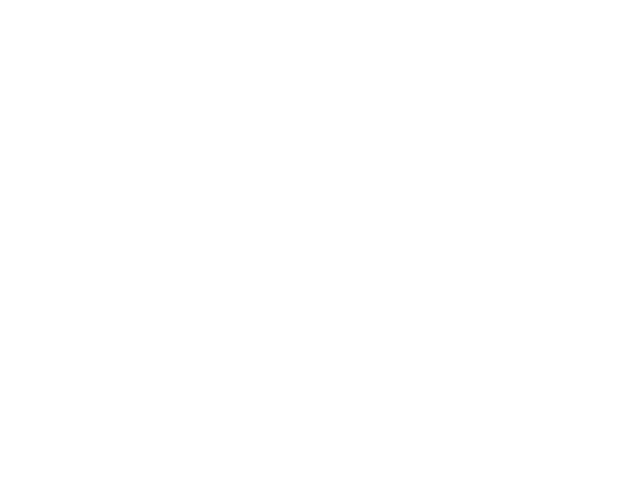

In [3]:
# Read the newly prepared Equiv. Black Carbon data (AE31 and AE33)
aerosol_data_dir="../data/level2/mkn/"
ds_ebc = read_aerosols.read_equivalent_black_carbon(aerosol_data_dir)

plt.figure()
ds_ebc['AE31_EBC_ug_m_3'].plot()
ds_ebc['AE33_EBC_ug_m_3'].plot()
ds_ebc["EBC_mean"].plot()
plt.show()


### Plotting

In [ ]:
# Remove outliers that exceed 10*stdedeviation and 4* the zscore (see )
# remove outliers or not
remove_outliers = False #remove outliers based ont uncertainty and statistics
remove_fire_events = True # remove spcific fire events (defined below)

#-----
fire_dates_Mar2022 = slice('2022-03-16','2022-03-29')
fire_times_Mar2022 = ds_aerosols.sel(time=fire_dates_Mar2022).time.values


fire_dates_Mar2021 = slice('2021-03-20','2021-03-28')
fire_times_Mar2021 = ds_aerosols.sel(time=fire_dates_Mar2021).time.values

ds_aerosols_rem_out = ds_aerosols.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!

if remove_fire_events:
    # remove fire events from the dataset. Use a workaround, because xarray adds time dimension to all variables
    ds_withtime = ds_aerosols.drop([ var for var in ds_aerosols.variables if not 'time' in ds_aerosols[var].dims ])
    ds_timeless = ds_aerosols.drop([ var for var in ds_aerosols.variables if     'time' in ds_aerosols[var].dims ])
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021
    ds_aerosols_rem_out = xr.merge([ds_timeless, ds_withtime])

if remove_outliers:
    outlier_masks = {}
    for var_name in np.unique(list(ds_aerosols.keys())[0:4]):
        print(f"remove outliers for {var_name}:")
        drop_vars = list(ds_aerosols.keys())
        drop_vars.remove(var_name)
        ds_removed_outliers, mask_no_outliers = process_data.rem_out(ds_aerosols_rem_out.drop(drop_vars),vars=[var_name], use_unc=False, std_fac=10, z_threshold=6,plot_timeseries=False)
        ds_aerosols_rem_out[var_name] = ds_removed_outliers[var_name]
        outlier_masks[var_name] = mask_no_outliers

      

#ds_aerosols = ds_aerosols_rem_out # use the removed outlier data!

## get a mask of excluded outliers to exclude the same in AAE, SAE, SSA!

In [ ]:
if remove_outliers:
    # decide which dataset to use as outlier criteria for all 
    species_out = "abs_coeff"
    mask_all = outlier_masks[species_out][-2] # define which species and wavelength to use as default mask for outliers
    # show excluded outliers
    plt.figure()
    var_name = 'abs_coeff'
    ds_aerosols.isel(lambda_abs=1)[var_name].plot(ls='--')
    ds_aerosols.where(mask_all).isel(lambda_abs=1)[var_name].plot(ls=':',label='with abs criteria') 
    ds_aerosols_rem_out.isel(lambda_abs=1)[var_name].plot() #same as previous
    plt.legend()
    plt.show()

    # show excluded outliers
    plt.figure()
    var_name = 'black_carbon'
    ds_aerosols.isel(lambda_abs=0)[var_name].plot(ls='--')
    ds_aerosols[var_name].where(outlier_masks[var_name]).isel(lambda_abs=0).plot(ls=':') 
    ds_aerosols_rem_out.isel(lambda_abs=0)[var_name].plot() #same as previous
    plt.show()

In [ ]:
## Select the time period and species to plot


tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

# Filter the data for the current period
period_data = ds_aerosols.sel(time=slice(tsel1, tsel2))

#my_aerosol_species = list(ds_aerosols.keys())   # = 'abs_coeff', 'scat_coeff', 'black_carbon', 'AAE', 'SAE', 'SSA'


aerosol_ds_to_plot = {
    #'abs_coeff_521' : period_data.sel(lambda_abs=521)['abs_coeff'],
    'abs_coeff_525' : period_data.sel(lambda_scat=525)['abs_coeff_interp'], #"interpolated" (with ) to same wavelengths as scattering
    'scat_coeff_525' : period_data.sel(lambda_scat=525)['scat_coeff'],
    'black_carbon_880' : period_data.sel(lambda_abs=880)['black_carbon'],
    'AAE' : period_data['AAE'],
    'SAE' : period_data['SAE'],
    'SSA' : period_data.sel(lambda_scat=525)['SSA']
    }
aerosol_subtitles =   {
    #'abs_coeff_521' : "Absorption coefficient (at 521nm)",
    'abs_coeff_525' : "Absorption coefficient (at 525nm)",
    'scat_coeff_525' : "Scattering coefficient (at 525nm)",
    'black_carbon_880' : "Black carbon (at 880nm)",
    'AAE' : "AAE (470nm/880nm)",
    'SAE' : "SAE (450nm/635nm)",
    'SSA' : "SSA (525nm)"
    }

# aerosol_ds_to_plot = {
#     'AAE' : period_data['AAE'],
#     'SAE' : period_data['SAE'],
#     'SSA' : period_data.sel(lambda_scat=525)['SSA']
#     }

# aerosol_subtitles =   {
#     'AAE' : "AAE (470/880)",
#     'SAE' : "SAE (450/635)",
#     'SSA' : "SSA (525)"
#     }

# aerosol_ds_to_plot = {
#     #'abs_coeff_521' : period_data.sel(lambda_abs=521)['abs_coeff'],
#     'abs_coeff_525' : period_data.sel(lambda_scat=525)['abs_coeff_interp'], #"interpolated" (with ) to same wavelengths as scattering
#     'scat_coeff_525' : period_data.sel(lambda_scat=525)['scat_coeff'],
#     'black_carbon_880' : period_data.sel(lambda_abs=880)['black_carbon']
#     }
# aerosol_subtitles =   {
#     #'abs_coeff_521' : "Absorption coefficient (at 521nm)",
#     'abs_coeff_525' : "Absorption coefficient (at 525nm)",
#     'scat_coeff_525' : "Scattering coefficient (at 525nm)",
#     'black_carbon_880' : "Black carbon (at 880nm)",
#     }

my_aerosol_species = list(aerosol_ds_to_plot.keys())


In [4]:
# Define fit paramaters for the curve fitting (NOAA approach)
from utils.ccg_filter import ccg_filter as ccgfilt
from utils.ccg_filter import ccg_dates
from utils import run_curve_fit

# Default values
fit_params_defaults = {'shortterm': 45, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 3, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # 1h
                'numharmonics': 4}

fit_properties = {}
for dataset in aerosol_ds_to_plot:
    dataset_name = dataset
    fit_properties[dataset_name] = fit_params_defaults.copy()

# Update fit_properties with non-default values if necessary:
# Remove sampleinterval for flask data:
# for dataset in fit_properties:
#     if 'abs_coeff_525' in dataset:
#         fit_properties[dataset]['shortterm'] = 20


NameError: name 'aerosol_ds_to_plot' is not defined

In [5]:
## Helper functions for the figure (copied from plotting/plot_curve_fits.ipynb)

import matplotlib.colors as mc
from labellines import labelLine, labelLines
import colorsys 

# adjust the lightness of a color
def adjust_lightness(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

# function to plot each subplot
# time series plot
def plot_data(ds_temp, ds_temp_fit, label,ax=None, detrend=False, plot_measurements=True, plot_fit=True, **kwargs):
    ''' 
    Plot the data and the fit
    detrend: if True, plot the detrended data
    '''
    if ax is None:
        ax = plt.gca()

    ## get initial figure properties
    initial_color = kwargs['color']
    initial_ls = kwargs['ls']
    
    if plot_measurements:
        kwargs['ls'] = '' #no line for measurements
        pl = ds_temp.plot(
            ax=ax,
            alpha=0.7,
            #label=label[0:4],
            #markeredgewidth=0,
            zorder=0,
            **kwargs
        )
    else:
        pl = []
    #plot fit
    if plot_fit:
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5) # adapt hue of initial color (lighter)
        kwargs['marker'] = '' #no marker for fit
        kwargs['ls'] = initial_ls
        pl_fit = ds_temp_fit["smoothed_vals"].plot(ax=ax, label=label, **kwargs)
        if detrend:
            #plot detrended fit
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8)  # adapt hue of initial color (darker)
            kwargs['ls'] = ':' #dotted line for detrended
            ax.plot(
                ds_temp_fit.time,
                ds_temp_fit["seasonal_detrend"] + ds_temp_fit["smoothed_vals"].mean(),
                label="detrended fit",
                zorder=5
                **kwargs,
            )  ## Add mean value to detrended to obtain same magnitude
    else:
        pl_fit = []
    return pl, pl_fit

# seasonality plot
def plot_cycle(ds_temp, ds_temp_fit, s, freq="month", ax=None, detrend = False, plot_smoothed=True, label='', **kwargs):
    '''
    Plot seasonal cycle of the data
    detrend:  if True, detrend teh seasonal cycle
    plot_smootehd:  Plot the smoothed or the original data
    '''
    
    ## get a different hue of the color used
    # Decrease the hue value
    initial_color = kwargs['color']
    
    if ax is None:
        ax = plt.gca()
    ref = (
        ds_temp.mean()
    )  # use mean value from measurements to obtain positive/neg. seasonality (ds_temp-ref) or absolute values (ds_temp_fit +ref)
    # ref_fit = (
    #     ds_temp_fit["smoothed_vals"].mean()
    # )

    if freq=='hour':
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
        xvals = (ds_temp-ref).groupby(f"time.{freq}").mean() #for daily data, smoothed data can not be used
        std = (ds_temp-ref).groupby(f"time.{freq}").std() 
        
        pl = xvals.plot(
            ax=ax, label=f"{label}",**kwargs
        )
        #add stdev
        ax.fill_between(xvals[freq],xvals,xvals+std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
        ax.fill_between(xvals[freq],xvals,xvals-std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
    else:
        # normal seasonal cycle
        if detrend==False:
            #kwargs['ls'] = ':' #dotted line for not detrended
            kwargs['color'] = adjust_lightness(initial_color,amount=1.5) # adapt hue of initial color (darker)
            #plot normal seasonal cycle (with normal trend)
            seas_label = f"{label} not detrended"           
        # detrended seasonal cycle
        else:
            kwargs['color'] = adjust_lightness(initial_color,amount=1.5)  # adapt hue of initial color (lighter)
            seas_label = label
            
        if plot_smoothed:
            xvals = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").mean()
            std = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").std() # standarddeviation of the grouped values of the measurements
        else:
            xvals = (ds_temp-ref).groupby(f"time.{freq}").mean()
            std = (ds_temp-ref).groupby(f"time.{freq}").std() 
            
        pl = xvals.plot(
            ax=ax, label=f"{seas_label}", **kwargs
        ) #label=f"{label} detrended"

        #add stdev
        ax.fill_between(xvals[freq],xvals,xvals+std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
        ax.fill_between(xvals[freq],xvals,xvals-std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
    return pl


In [ ]:
%autoreload 2

##---- Plotting definitions ----##
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
detrend = False #if true, detrend the seasonal data
plot_smooth = True # use smoothed or normal data in seasonal cycle

default_colors = ['C0', 'C1', 'C2', 'C3'] 
color_iterator = itertools.cycle(default_colors)

##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in list(aerosol_ds_to_plot.keys())] # put [] around to start new row
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_aerosol_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, len(my_aerosol_species) * subfig_height),
                              layout="constrained")
                              



# Define figure properties for this period
fig_properties = {
    'color': next(color_iterator),
    'marker': '.',
    'ls':'-'
}

## Loop through all datasets and plot the data
for i, (species,data) in enumerate(aerosol_ds_to_plot.items()):
    print(f"Dataset:  {species}")

    if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
    
        # Define fit properties for this dataset
        # Perform the curve fitting and obtain the interpolated time axis
        filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
            ds=data,
            dataset_str=species,
            t1=tsel1,
            t2=tsel2,
            debug = False,
            **fit_properties[species]
        )
            
        # Plot the data and the fit
        # normal properties
        fig_properties['marker'] = '.'
        fig_properties['ls'] = '-'

        
        ## Time series figure
        ax_ts = axd[species]
        ## Seasonal cycle figure
        ax_seas = axd[species+'_seas']


        legend_entry = f"curve fit ({fit_properties[species]['shortterm']} days)"
        plot_data(data,                       
                    ds_interp,
                    legend_entry, 
                    ax_ts,
                    detrend
                    ,**fig_properties)

        #plot seasonal cycle
        freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
        # no markers for seasonal cycle
        fig_properties['marker'] = '' #no marker for seasonal cycle
        pl_seas = plot_cycle(
            data,
            ds_interp,
            species,
            freq= freq,
            ax=ax_seas,
            detrend=detrend,
            plot_smoothed = plot_smooth,
            label = species,
            **fig_properties
        )


        #---- figure properties ----#

        # axes properties time series
        ax_ts.set_ylabel(f"{species} ({data.unit})")
        ax_ts.set_title(aerosol_subtitles[species],loc='left')
        #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
        ax_ts.spines["top"].set_visible(False)
        ax_ts.spines["right"].set_visible(False)
        ax_ts.set_title("")

        if species != my_aerosol_species[-1]:  # all except lowest axis
            plt.setp(
                ax_ts.get_xticklabels(), visible=False
            )  # remove xticklabels except for lowest plot
            ax_ts.set_xlabel("")

        # axes properties seasonal cycle
        # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
        #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
        ax_seas.set_title("")
        ax_seas.set_ylabel("")
        ax_seas.spines["top"].set_visible(False)
        ax_seas.spines["right"].set_visible(False)
        if plot_seas:
            if freq== 'month':
                months = range(1, 13, 3)
                ax_seas.set_xticks(
                    months,
                    [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                )
            elif freq == 'dayofyear':
                ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
        ax_seas.set_axisbelow(False)

        # different for lowest plot
        if species != my_aerosol_species[-1]:  # all except lowest axis
            plt.setp(
                ax_seas.get_xticklabels(), visible=False
            )  # remove xticklabels except for lowest plot
            ax_seas.set_xlabel("")

## --- Final figure properties ---##
handles, labels = ax_ts.get_legend_handles_labels()
# manually adapt legend:
labels[0] = "1h data"
ax0 = list(axd.values())[0] #first subplot (upper left)
if detrend:
    ax0.legend(handles, labels, loc="lower right")
fig.align_ylabels()

# # Add a manual legend showing the shape of the dots to the lower left subplot
# marker_flask = mlines.Line2D([], [], color='k', marker='x', linestyle='None', label='Flask data')
# marker_other = mlines.Line2D([], [], color='k', marker='.', linestyle='None',label='Continuous data')
# ax0.legend(handles=[marker_flask,marker_other], loc='upper left')

# # Add the legend to the upper right subplot (cycles)
# ax_sel = axd[my_aerosol_species[0] +'_seas']
# handles, labels = ax_sel.get_legend_handles_labels()
# labelLines(ax_sel.get_lines(), zorder=2.5)
# #ax_sel.legend(handles, labels, loc='upper left')

# place title on first axis
fig.suptitle("Mt. Kenya aerosol measurements and curve fit")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = "Seasonal cycle"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")


str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if detrend else ''
str_freq = '_' + seas_freq if plot_seas else ''





# if not all species are plotted: adapt name
if len(my_aerosol_species) <4:
    str_spec = '_' + '_'.join(my_aerosol_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}aerosol_timeseries_and_{str_seas}{str_freq}_fit{str_trend}_from2020{str_spec}.png", dpi=300
    )

In [ ]:
## Same figure but for different wavelengths

aerosol_ds_to_plot = {
    #'abs_coeff_521' : period_data.sel(lambda_abs=521)['abs_coeff'],
    'abs_coeff' : period_data['abs_coeff_interp'], #"interpolated" (with ) to same wavelengths as scattering
    'scat_coeff' : period_data['scat_coeff'],
    'black_carbon_880' : period_data.sel(lambda_abs=880)['black_carbon'],
    'AAE' : period_data['AAE'],
    'SAE' : period_data['SAE'],
    'SSA' : period_data['SSA']
    }
aerosol_subtitles =   {
    'abs_coeff' : "Absorption coefficient",
    'scat_coeff' : "Scattering coefficient",
    'black_carbon_880' : "Black carbon (at 880nm)",
    'AAE' : "AAE (470nm/880nm)",
    'SAE' : "SAE (450nm/635nm)",
    'SSA' : "SSA"
    }
my_aerosol_species = list(aerosol_ds_to_plot.keys())

fit_properties = {}
for dataset in aerosol_ds_to_plot:
    dataset_name = dataset
    fit_properties[dataset_name] = fit_params_defaults.copy()


##---- Plotting definitions ----##
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
detrend = False #if true, detrend the seasonal data
plot_smooth = True # use smoothed or normal data in seasonal cycle

default_colors = ['C0', 'C1', 'C2', 'C3'] 
color_iterator = itertools.cycle(default_colors)

##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in list(aerosol_ds_to_plot.keys())] # put [] around to start new row
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_aerosol_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, len(my_aerosol_species) * subfig_height),
                              layout="constrained")
                              



# Define figure properties for this period
fig_properties = {
    'color': next(color_iterator),
    'marker': '.',
    'ls':'-'
}

for ii,(wavelength,col) in enumerate(zip(ds_aerosols.lambda_scat,['tab:blue','tab:green','tab:red'])):
    ## Loop through all datasets and plot the data
    for i, (species,data) in enumerate(aerosol_ds_to_plot.items()):
        print(f"Dataset:  {species}")

        if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
            
            if species not in(['AAE','SAE', 'black_carbon_880']):
                data = data.sel(lambda_scat=wavelength,drop=True)
                fig_properties['color'] = col
                legend_entry = f"{int(wavelength.values)}nm"
            else: 
                legend_entry = f"curve fit ({fit_properties[species]['shortterm']} days)"
                if ii>0: # plot the subplots that are not wavelength dependent only once
                    continue
            # Define fit properties for this dataset
            # Perform the curve fitting and obtain the interpolated time axis
            filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                ds=data,
                dataset_str=species,
                t1=tsel1,
                t2=tsel2,
                debug = False,
                **fit_properties[species] # use same default parameters for all
            )
                
            # Plot the data and the fit
            # normal properties
            fig_properties['marker'] = '.'
            fig_properties['ls'] = '-'
            
            ## Time series figure
            ax_ts = axd[species]
            ## Seasonal cycle figure
            ax_seas = axd[species+'_seas']


            
            plot_data(data,                       
                        ds_interp,
                        legend_entry, 
                        ax_ts,
                        detrend
                        ,**fig_properties)

            #plot seasonal cycle
            freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
            # no markers for seasonal cycle
            fig_properties['marker'] = '' #no marker for seasonal cycle
            pl_seas = plot_cycle(
                data,
                ds_interp,
                species,
                freq= freq,
                ax=ax_seas,
                detrend=detrend,
                plot_smoothed = plot_smooth,
                label = species,
                **fig_properties
            )


            #---- figure properties ----#

            # axes properties time series
            ax_ts.set_ylabel(f"{species} ({data.unit})")
            ax_ts.set_title(aerosol_subtitles[species],loc='left')
            #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
            ax_ts.spines["top"].set_visible(False)
            ax_ts.spines["right"].set_visible(False)
            ax_ts.set_title("")
            ax_ts.legend(ncol=3)

            if species != my_aerosol_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_ts.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_ts.set_xlabel("")

            # axes properties seasonal cycle
            # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
            #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
            ax_seas.set_title("")
            ax_seas.set_ylabel("")
            ax_seas.spines["top"].set_visible(False)
            ax_seas.spines["right"].set_visible(False)
            if plot_seas:
                if freq== 'month':
                    months = range(1, 13, 3)
                    ax_seas.set_xticks(
                        months,
                        [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                    )
                elif freq == 'dayofyear':
                    ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                    ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

            #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
            ax_seas.set_axisbelow(False)

            # different for lowest plot
            if species != my_aerosol_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_seas.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_seas.set_xlabel("")

## --- Final figure properties ---##
# handles, labels = ax_ts.get_legend_handles_labels()
# # manually adapt legend:
# labels[0] = "1h data"
# ax0 = list(axd.values())[0] #first subplot (upper left)
# if detrend:
#     ax0.legend(handles, labels, loc="lower right")

fig.align_ylabels()



# place title on first axis
fig.suptitle("Mt. Kenya aerosol measurements and curve fit")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = "Seasonal cycle"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")


str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if detrend else ''
str_freq = '_' + seas_freq if plot_seas else ''


# if not all species are plotted: adapt name
if len(my_aerosol_species) <4:
    str_spec = '_' + '_'.join(my_aerosol_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}aerosol_timeseries_and_{str_seas}{str_freq}_fit{str_trend}_from2020{str_spec}_3wavelengths.png", dpi=300
    )

### Compare with gas measurements

In [ ]:
## Read all GHG data
%autoreload 2
from input.read_wdc_data import AvailableData, create_data_reader

# File path
data_path = "../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


In [ ]:
ds_all_rem_out = ds_all.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!
for ds in np.unique(ds_all.species):
    print(f"remove outliers for {ds}:")
    ds_all_rem_out.loc[dict(dataset=ds)], mask_out = process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)

#ds_all = ds_all_rem_out # use the removed outlier data!

In [ ]:
## Figure for Black carbon vs. CO
tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

species_ghg = "CO"
species_aer = 'black_carbon'

ghg_sel = ds_all.sel(time=slice(tsel1, tsel2), dataset=species_ghg, drop=True)
aer_sel = ds_aerosols.sel(lambda_abs=880)[species_aer]

fig, ax = plt.subplots(figsize=(6, 4))
alpha = 0.8
ms = 8

pl_ghg = ghg_sel["value"].plot(
    marker=".",
    ls="-",
    label=species_ghg,
    alpha=alpha,
    markeredgewidth=0,
    markersize=ms,
    ax=ax,
        color='C1'
)
plt.legend(loc='upper left')
ax2 = ax.twinx()
pl_aer = aer_sel.plot(
    marker=".",
    ls="-",
    label=species_aer,
    alpha=alpha,
    markeredgewidth=0,
    markersize=ms,
    ax=ax2,
    color='C0'
)
plt.legend()

mw_days = 5  # moving window days
mw = 3 * 8 * mw_days  #  moving windowplt.ylabel("CO2 (ppm)")
plt.xlabel("Time")
plt.legend()
plt.title("Mt. Kenya GAW station: \n COobservations and Black carbon")
form_xdate(ax, "Y", 1, "")
fig_format = "png"
plt.tight_layout()
plt.savefig(fr'.\output\aerosols\timseries_CO_BC.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')


In [ ]:
# same but CO and black carbon figure with curve fit
species_ghg = "CO"
species_aer = 'black_carbon'

ghg_sel = ds_all.sel(time=slice(tsel1, tsel2), dataset=species_ghg, drop=True)
aer_sel = ds_aerosols.sel(lambda_abs=880,time=slice(tsel1, tsel2))[species_aer]

# add unit to CO data in same format as for aerosol: 
ghg_sel['value'].attrs["unit"] = ghg_sel['unit'].values


aerosol_ghg_to_plot = {
    species_ghg : ghg_sel['value'],
    'black_carbon_880' : period_data.sel(lambda_abs=880)['black_carbon'],
    #'BC/CO' : period_data.sel(lambda_abs=880)['black_carbon'] / ghg_sel['value'] 
    }
# add fit params for CO
fit_properties[species_ghg] = fit_params_defaults.copy()
#fit_properties['BC/CO'] = fit_params_defaults.copy()

my_aerosol_ghg_species = list(aerosol_ghg_to_plot.keys()) 


##---- Plotting definitions ----##
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
detrend = False #if true, detrend the seasonal data

one_figure_only = False # plot different species in same figure

default_colors = ['C0', 'C1', 'C2', 'C3'] 
color_iterator = itertools.cycle(default_colors)

##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m, m+'_seas']  for m in list(aerosol_ghg_to_plot.keys())] # put [] around to start new row
if one_figure_only:
    mosaic_grids =  [[list(aerosol_ghg_to_plot.keys())[0],list(aerosol_ghg_to_plot.keys())[0]+'_seas'] ] 
gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
subfig_height = 2.5 if len(my_aerosol_ghg_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(8, 2 * subfig_height),
                              layout="constrained")
                              


# Define figure properties for this period
fig_properties = {
    'color': next(color_iterator),
    'marker': '.',
    'ls':'-'
}

## Loop through all datasets and plot the data
for i, (species,data) in enumerate(aerosol_ghg_to_plot.items()):
    print(f"Dataset:  {species}")

    if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
    
        # Define fit properties for this dataset
        # Perform the curve fitting and obtain the interpolated time axis
        filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
            ds=data,
            dataset_str=species,
            t1=tsel1,
            t2=tsel2,
            **fit_properties[species]
        )
            
        # Plot the data and the fit
        # normal properties
        fig_properties['marker'] = '.'
        fig_properties['ls'] = '-'

        
        ## Time series figure
        ax_ts = axd[list(aerosol_ghg_to_plot.keys())[0]] if one_figure_only else axd[species]
        ## Seasonal cycle figure
        ax_seas = axd[list(aerosol_ghg_to_plot.keys())[0]+'_seas'] if one_figure_only else axd[species+'_seas']

        legend_entry = f"curve fit ({fit_properties[species]['shortterm']} days)"
        plot_data(data,                       
                    ds_interp,
                    legend_entry, 
                    ax_ts,
                    detrend
                    ,**fig_properties)

        #plot seasonal cycle
        freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
        # no markers for seasonal cycle
        fig_properties['marker'] = '' #no marker for seasonal cycle
        pl_seas = plot_cycle(
            data,
            ds_interp,
            species,
            freq= freq,
            ax=ax_seas,
            detrend=detrend,
            label = species,
            **fig_properties
        )


        #---- figure properties ----#

        # axes properties time series
        ax_ts.set_ylabel(f"{species} ({data.unit})")
        #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
        ax_ts.spines["top"].set_visible(False)
        ax_ts.spines["right"].set_visible(False)
        ax_ts.set_title("")

        if species != my_aerosol_species[-1]:  # all except lowest axis
            plt.setp(
                ax_ts.get_xticklabels(), visible=False
            )  # remove xticklabels except for lowest plot
            ax_ts.set_xlabel("")

        # axes properties seasonal cycle
        # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
        #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
        ax_seas.set_title("")
        ax_seas.set_ylabel("")
        ax_seas.spines["top"].set_visible(False)
        ax_seas.spines["right"].set_visible(False)
        if plot_seas:
            if freq== 'month':
                months = range(1, 13, 3)
                ax_seas.set_xticks(
                    months,
                    [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                )
            elif freq == 'dayofyear':
                ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
        ax_seas.set_axisbelow(False)

        # different for lowest plot
        if species != my_aerosol_species[-1]:  # all except lowest axis
            plt.setp(
                ax_seas.get_xticklabels(), visible=False
            )  # remove xticklabels except for lowest plot
            ax_seas.set_xlabel("")

## --- Final figure properties ---##
handles, labels = ax_ts.get_legend_handles_labels()
# manually adapt legend:
labels[0] = "1h data"
ax0 = list(axd.values())[0] #first subplot (upper left)
if detrend:
    ax0.legend(handles, labels, loc="lower right")
fig.align_ylabels()

# # Add a manual legend showing the shape of the dots to the lower left subplot
# marker_flask = mlines.Line2D([], [], color='k', marker='x', linestyle='None', label='Flask data')
# marker_other = mlines.Line2D([], [], color='k', marker='.', linestyle='None',label='Continuous data')
# ax0.legend(handles=[marker_flask,marker_other], loc='upper left')

# # Add the legend to the upper right subplot (cycles)
# ax_sel = axd[my_aerosol_species[0] +'_seas']
# handles, labels = ax_sel.get_legend_handles_labels()
# labelLines(ax_sel.get_lines(), zorder=2.5)
# #ax_sel.legend(handles, labels, loc='upper left')

# place title on first axis
ax0.set_title(f"Mt. Kenya aerosol measurements and curve fit ({fit_properties['CO']['shortterm']} days)", loc="left")
ax1 = list(axd.values())[1] #second subplot (upper right)
if plot_seas:
    tit_right = "Seasonal cycle"
else:
    tit_right = 'Diurnal cycle'
ax1.set_title(tit_right, loc="center")


# # plot in each subplot a vertical line for the compare_periods (not working yet)
# for ax in axd.values():
#     if '_seas' in ax.get_label():
#         continue
#     else: 
#         for period, (start_date, end_date) in compare_periods.items():
#             ax.axvline(start_date, color='k', linestyle='--', alpha=0.5)
#             ax.axvline(end_date, color='k', linestyle='--', alpha=0.5)
#             # Create a rectangle patch with transparent background
#             #rect = plt.Rectangle((start_date, ax.get_ylim()[0]), end_date - start_date, ax.get_ylim()[1], facecolor=next(color_iterator), edgecolor='none')
#             # Add the rectangle patch to the plot
#             #ax.add_patch(rect)



str_seas = 'seas' if plot_seas else 'daily'
str_trend = '_detrended' if detrend else ''
str_freq = '_' + seas_freq if plot_seas else ''





# if not all species are plotted: adapt name
if len(my_aerosol_species) <4:
    str_spec = '_' + ''.join(my_aerosol_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}blackcarbon_CO_timeseries_and_{str_seas}{str_freq}_fit{str_trend}_from2020_{str_spec}.png", dpi=300
    )

### Scatter plot

In [ ]:
from sklearn.linear_model import LinearRegression

## Black carbon vs. CO for different months (using daily data)


x = ds_aerosols.sel(time=slice(tsel1,tsel2),lambda_abs=880)[species_aer].resample(time="1D").mean()*1000 #in ng/m3
y = ds_all.sel(time=slice(tsel1, tsel2), dataset=species_ghg, drop=True)['value'].resample(time="1D").mean()

months = x.time.dt.month

# Define a colormap for months
colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
colors = colmap(np.linspace(0, 1, 12))

fig, ax = plt.subplots(
    1, 1, figsize=(5,5), sharey=True, sharex=True, layout="constrained"
)

# all months scatter with linear fits
scatter = ax.scatter(x.values, y.values, c=months, cmap=colmap, alpha=1)
## add line fits:
# Iterate over unique months and fit a line for each month

vals_months = {}
r2_months = []
slope_months = []
for month, c in zip(range(1, 13), colors):
    # Filter data for the current month
    x_month = x.where(x.time.dt.month == month, drop=True)
    y_month = y.where(y.time.dt.month == month, drop=True)

    # remove nans
    y_month_non_nan = y_month.dropna(dim="time")
    x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True)

    x_month_non_nan = x_month_non_nan.dropna(dim="time")
    y_month_non_nan = y_month_non_nan.sel(time=x_month_non_nan.time.values, drop=True)

    if len(x_month) > 1:
        # Fit a linear regression model
        model = LinearRegression()
        model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

        # Predictions
        x_pred = np.linspace(
            x.min(), x.max(), 2
        )  # create x-values for which to predict y-values
        y_pred = model.predict(x_pred.reshape(-1, 1))

        # Plot the line fit for the current month
        r2 = model.score(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)
        slope = model.coef_[0]
        month_str = dt.datetime.strptime(str(month), "%m").strftime("%b")
        r2_months.append(r2)
        slope_months.append(slope)
        ax.plot(
            #x_pred, y_pred, color=c, label=f"{month_str} ({r2:.2f}, {slope:.2f})"
            x_pred, y_pred, color=c, label=f"{month_str}"
        )  # color=colmap(month / 13)
        # ax.plot(x_pred, y_pred, color=colmap(month / 13), label=f'Month {month}')
    else:
        print(f"no fit for month {month}")
    legend1 = ax.legend(ncols=4,
        loc="upper right", #title="Months (R2, slope)"
)
vals_months['R2'] = r2_months
vals_months['Slope'] = slope_months
ax.add_artist(legend1)

ax.set_ylabel(f"CO (ppb)")
ax.set_xlabel("Black Carbon (ng/m3)")

# general figure properties
plt.setp(ax, box_aspect=1)  # get quadratic plots

plt.suptitle(
    "Daily CO vs. black carbon \n at Mt. Kenya for different months"
)
if save_fig:
    plt.savefig(f"{dir_save}scatter_BC_CO.png",dpi=400)
plt.show()

In [ ]:
# make a barplot of the dictionary r2_months
months_str = [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in range(1,13)]

fig, ax = plt.subplots(figsize=(6,2))
plt.bar(months_str,list(vals_months['R2']))
plt.title('R2 of CO vs. Black carbon')
if save_fig:
    plt.savefig(f"{dir_save}R2_months_BC_CO.png",dpi=400)
plt.show()

In [ ]:
months_str = [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in range(1,13)]
x = np.arange(len(months_str))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(6,2),layout='constrained')

for attr, vals in vals_months.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, vals, width, label=attr)
    #ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_xticks(x + width, months_str)
ax.legend(loc='upper right', ncols=3)
plt.title('R2 and slope of CO vs. Black carbon')

if save_fig:
    plt.savefig(f"{dir_save}R2_slope_months_BC_CO.png",dpi=400)


## Remove background

In [ ]:
# plot the percentile and the delta for CO
mw = 24 * 45  # 24 * days (data given in hours)
quantile_value = 10

ds_sel = ds_all_rem_out.sel(time=slice(tsel1, tsel2), dataset=species_ghg, drop=True)
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax0 = axs[0]
ax1 = axs[1]
ds_sel.value.plot(marker=".", color="dimgrey", ls="", ax=ax0,zorder=0)
percentile_10th = (
    ds_sel.value.rolling(time=mw, center=True).construct("tmp").quantile(quantile_value/100, dim="tmp")
)
percentile_10th.plot(
    marker=".", ls="-", color="k", lw=1,ax=ax0, label=f'moving {quantile_value}th percentile ({int(mw/24)}days)',zorder=2
)  # take 3days windows and for each window the 10%-quantile

# plot the background and the difference to this "background":
mask_is_background_co = ds_sel.value < percentile_10th
# plot the "background":
ds_sel.value[mask_is_background_co].plot(color='lightgrey',ls='',marker='.',ax=ax0,label='background',zorder=1)

#plot the remaining data in second axes ("local contamination")
delta_co = ds_sel.value - percentile_10th
delta_co.where(delta_co > 0).plot(
    ax=ax1, color='dimgrey'
)  # plot all data that are larger than the "background" in new subplot
ax0.set_xlabel('')
ax1.set_title("")
ax1.set_title("Delta CO (data-background)", loc="left")
ax0.legend()
plt.show()

In [ ]:
# plot the percentile and the delta black carbon
mw = 24 * 45  # 24 * days (data given in hours)
quantile_value = 10

species_aer = 'black_carbon'
ds_sel = ds_aerosols_rem_out.sel(lambda_abs=880,time=slice(tsel1, tsel2))[species_aer]

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax0 = axs[0]
ax1 = axs[1]
ds_sel.plot(marker=".", color="dimgrey", ls="", ax=ax0,zorder=0)
percentile_10th = (
    ds_sel.rolling(time=mw, center=True).construct("tmp").quantile(quantile_value/100, dim="tmp")
)
percentile_10th.plot(
    marker=".", ls="-", color="k", lw=1,ax=ax0, label=f'moving {quantile_value}th percentile ({int(mw/24)}days)',zorder=2
)  # take 3days windows and for each window the 10%-quantile

# plot the background and the difference to this "background":
mask_is_background_co = ds_sel < percentile_10th
# plot the "background":
ds_sel[mask_is_background_co].plot(color='lightgrey',ls='',marker='.',ax=ax0,label='background',zorder=1)

#plot the remaining data in second axes ("local contamination")
delta_bc = ds_sel - percentile_10th
delta_bc.where(delta_bc > 0).plot(
    ax=ax1, color='dimgrey'
)  # plot all data that are larger than the "background" in new subplot
ax0.set_xlabel('')
ax1.set_title("")
#ax1.set_title("Delta CO (data-background)", loc="left")
ax0.legend()
plt.show()

In [ ]:

sampling = '1D'
fig, axs = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
x = delta_bc.where(delta_bc > 0).resample(time=sampling).mean()##*1000 # I think BC is given in mu g, *1000 to have it in ng
y= delta_co.where(delta_co > 0).resample(time=sampling).mean()
(x/y).groupby(f"time.dayofyear").mean().plot()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

## Black carbon vs. CO for different months (using daily data)


sampling = '1D'
x = (delta_bc*1000).where(delta_bc > 0).resample(time=sampling).mean()
y= delta_co.where(delta_co > 0).resample(time=sampling).mean()

months = x.time.dt.month

# Define a colormap for months
colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
colors = colmap(np.linspace(0, 1, 12))

fig, ax = plt.subplots(
    1, 1, figsize=(5,5), sharey=True, sharex=True, layout="constrained"
)

# all months scatter with linear fits
scatter = ax.scatter(x.values, y.values, c=months, cmap=colmap, alpha=1)
## add line fits:
# Iterate over unique months and fit a line for each month

vals_months = {}
r2_months = []
slope_months = []
for month, c in zip(range(1, 13), colors):
    # Filter data for the current month
    x_month = x.where(x.time.dt.month == month, drop=True)
    y_month = y.where(y.time.dt.month == month, drop=True)

    # remove nans
    y_month_non_nan = y_month.dropna(dim="time")
    x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True)

    x_month_non_nan = x_month_non_nan.dropna(dim="time")
    y_month_non_nan = y_month_non_nan.sel(time=x_month_non_nan.time.values, drop=True)

    if len(x_month) > 1:
        # Fit a linear regression model
        model = LinearRegression()
        model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

        # Predictions
        x_pred = np.linspace(
            x.min(), x.max(), 2
        )  # create x-values for which to predict y-values
        y_pred = model.predict(x_pred.reshape(-1, 1))

        # Plot the line fit for the current month
        r2 = model.score(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)
        slope = model.coef_[0]
        month_str = dt.datetime.strptime(str(month), "%m").strftime("%b")
        r2_months.append(r2)
        slope_months.append(slope)
        ax.plot(
            x_pred, y_pred, color=c, label=f"{month_str} ({r2:.2f}, {slope:.2f})"
        )  # color=colmap(month / 13)
        # ax.plot(x_pred, y_pred, color=colmap(month / 13), label=f'Month {month}')
    else:
        print(f"no fit for month {month}")
    legend1 = ax.legend(
        loc="upper right", title="Months (R2, slope)"
)
vals_months['R2'] = r2_months
vals_months['Slope'] = slope_months
ax.add_artist(legend1)

ax.set_ylabel(f"$\Delta$CO")
ax.set_xlabel("$\Delta$Black Carbon")

# general figure properties
plt.setp(axs, box_aspect=1)  # get quadratic plots

plt.suptitle(
    "Background CO vs. black carbon \n at Mt. Kenya for different months"
)
if save_fig:
    plt.savefig(f"{dir_save}scatter_dBC_dCO_{sampling}.png",dpi=400)
plt.show()

In [ ]:
months_str = [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in range(1,13)]
x = np.arange(len(months_str))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(6,2),layout='constrained')

for attr, vals in vals_months.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, vals, width, label=attr)
    #ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_xticks(x + width, months_str)
ax.legend(loc='upper left', ncols=3)
plt.title('R2 and slope of Delta_CO vs. Delta(Black carbon)')

if save_fig:
    plt.savefig(f"{dir_save}R2_slope_months_dBC_dCO_{sampling}.png",dpi=400)


### Check GFAS-derived BC data (footprint-weighted)

In [ ]:
## Read in GFAS-derived flexpart BC: 
bc_flexpart = xr.open_mfdataset('../data/level3/flexpart/weighted_bc_ts_values_2975m_2023.nc') # ACHTUNG: first month is not the same release_height! need to fold it again!


In [ ]:
plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)
(ds_aerosols.isel(lambda_abs=0)['black_carbon'].sel(time=slice('2023-01-01', '2023-12-31')).resample(time='1D').mean()).plot(label='BC data (ng/m3)')
#(delta_bc.where(delta_bc > 0)).sel(time=slice('2023-01-01', '2023-12-31')).plot(label='BC data above background (10th percentile)')
((bc_flexpart['bc_contribution'])*1e12).plot(label='BC contribution from fires (flexpart)') # convert from kg/m3 to ng/m3 

plt.legend()
plt.show()